## Principal Component Analysis (PCA)

### 1. Loading data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

data_path = "data/pca/cleaned_data.csv"
df = pd.read_csv(data_path, sep=",")
df.head()

,WELL,DEPTH_MD,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,BS,ROP,DRHO,LITHOLOGY
0,15/9-15,1149.648,HORDALAND GP.,Utsira Fm.,17.482092,1.502680,1.502680,1.714187,2.063168,68.388885,0.541850,2.583011,134.226379,64.088852,17.5,23.217106,0.026319,65000
1,15/9-15,1149.800,HORDALAND GP.,Utsira Fm.,17.395611,1.505071,1.505071,1.716345,2.051136,71.170013,0.545401,2.506672,134.824799,65.575722,17.5,22.635521,0.019921,65000
2,15/9-15,1149.952,HORDALAND GP.,Utsira Fm.,17.364607,1.525162,1.525162,1.719259,2.041540,74.497498,0.548953,2.427594,135.037079,66.153511,17.5,21.852139,0.014932,65000
3,15/9-15,1150.104,HORDALAND GP.,Utsira Fm.,17.371887,1.541443,1.541443,1.723307,2.035698,76.098335,0.549356,2.401553,134.500336,64.918488,17.5,21.146048,0.009946,65000
4,15/9-15,1150.256,HORDALAND GP.,Utsira Fm.,17.370705,1.542996,1.542996,1.729302,2.029099,74.966675,0.543351,2.358777,132.162399,64.066925,17.5,20.553537,0.005706,65000


#### Display number of samples per well

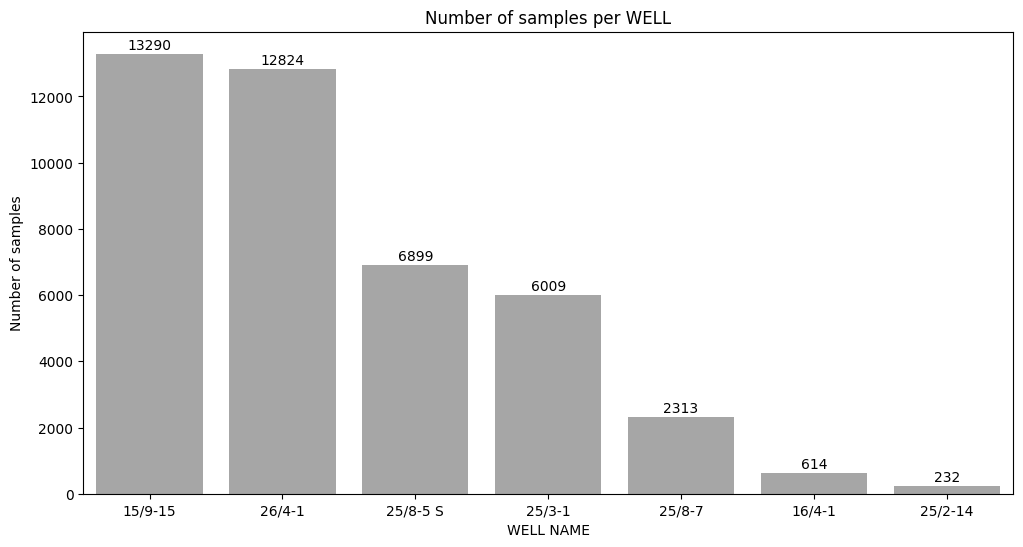

In [2]:
# Re-order column by descending values
well_counts = df.WELL.value_counts().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=well_counts.index, y=well_counts.values, color='grey', alpha=0.7)
plt.title("Number of samples per WELL")
plt.xlabel("WELL NAME")
plt.ylabel("Number of samples")
plt.xticks(rotation=0)

# Add the value on top of each bar
for i, value in enumerate(well_counts.values):
    plt.text(i, value + 50, str(value), ha='center', va='bottom')

plt.show()

### 2. Label checking

In [3]:
# Save the Label 
DFLabel = df["LITHOLOGY"]

# Print the labels
print(f"There are {len(DFLabel)} types of lithology and it represents by the following codes: ", DFLabel.unique())

There are 42181 types of lithology and it represents by the following codes:  [65000 65030 30000 70000 99000 80000 70032 90000 74000]


### 3. Remove categories columns

In [4]:
# Drop categorical columns
pca_df = df.drop(['FORMATION', 'WELL', 'LITHOLOGY', 'GROUP', 'BS'], axis=1)
display(pca_df.describe())
feature_names= pca_df.columns
print(f"Number of features: {len(feature_names)}, \nFeatures: {feature_names}")

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,NPHI,PEF,DTC,SP,ROP,DRHO
count,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000,42181.000000
mean,2426.485856,11.854190,2.762909,4.668206,4.693303,2.294450,71.477808,0.397697,5.823347,107.291108,48.998032,22.657302,0.022613
std,721.828772,3.093467,11.856220,38.307630,55.783676,0.255689,32.498219,0.198608,5.856255,30.186918,138.137142,17.986234,0.052292
min,761.041604,7.325138,0.005141,0.262247,0.264479,1.239131,6.024419,0.014492,1.074626,7.415132,-266.566284,0.069603,-0.489363
25%,1863.174400,9.043562,0.841600,0.786579,0.686648,2.081967,54.144875,0.255004,3.288399,82.151833,38.700779,8.395054,-0.011185
50%,2301.200000,12.342676,1.193334,1.280654,1.231505,2.312593,72.021515,0.361658,4.257130,99.381676,66.653862,16.497211,0.007328
75%,3058.464000,13.364419,2.797484,3.580580,3.043633,2.532267,88.355316,0.500045,6.426693,134.931549,108.100883,33.563400,0.044417
max,3907.120000,25.717396,779.958923,1988.616333,1999.877808,2.894546,1076.963867,0.999570,288.103638,205.208664,273.084320,236.408310,0.308971


Number of features: 13, 
Features: Index(['DEPTH_MD', 'CALI', 'RSHA', 'RMED', 'RDEP', 'RHOB', 'GR', 'NPHI', 'PEF',
       'DTC', 'SP', 'ROP', 'DRHO'],
      dtype='object')


In [6]:
pca_df.to_csv("data/pca/no_categorical_data.csv", index=False)

### 4. Standardization

In [7]:
from sklearn.preprocessing import StandardScaler

#Instantiate
scaler = StandardScaler() 
# Scale data
pca_df = scaler.fit_transform(pca_df)

print("DF Type:", type(pca_df))
print("DF Shape:", pca_df.shape)
print("The first sample of normalized data: \n", pca_df[:1])

DF Type: <class 'numpy.ndarray'>
DF Shape: (42181, 13)
The first sample of normalized data: 
 [[-1.76891396  1.81930799 -0.10629388 -0.08263531 -0.05340543 -0.90455789
  -0.0950501   0.72582432 -0.55331858  0.89229349  0.1092465   0.03112436
   0.07087746]]


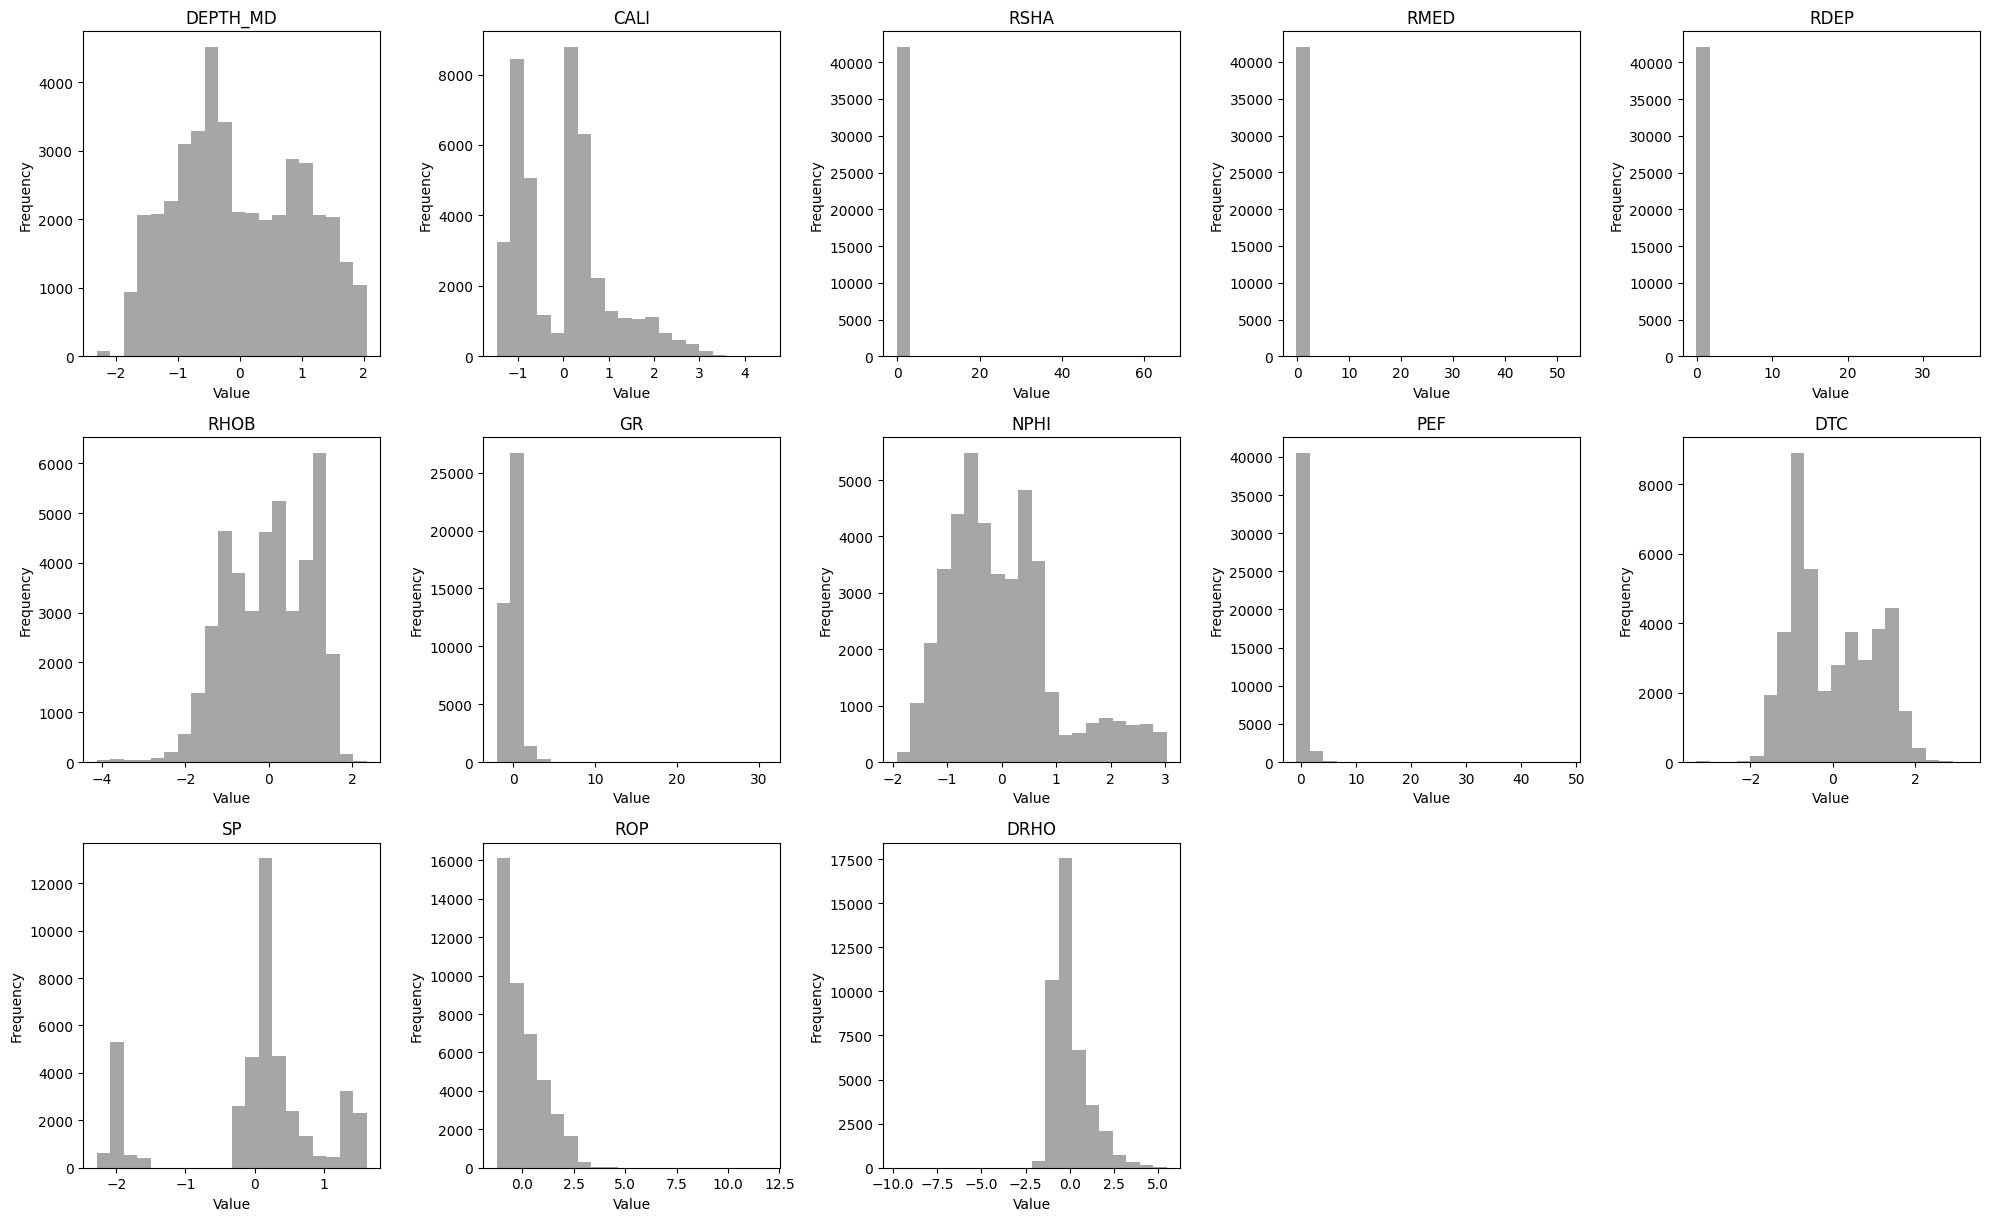

In [10]:
# pca_df to DataFrame
normalized_pca_df = pd.DataFrame(pca_df, columns=feature_names)
normalized_pca_df.describe()

# Plot all histogram of features using grid
plt.figure(figsize=(20, 20))
for i in range(len(feature_names)):
    plt.subplot(5, 5, i+1)
    plt.hist(normalized_pca_df[feature_names[i]], bins=20, color='grey', alpha=0.7)
    plt.title(feature_names[i])
    plt.xlabel("Value")
    plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

In [11]:
normalized_pca_df.to_csv("data/pca/normalized_data.csv", index=False)

### 5. PCA with `n_components = 2`

The eigenvalues: [4.36905568 1.53664608]
Some first samples of the transformed data: 
 [[ 2.42653505  0.22702105]
 [ 2.43283466  0.13501467]
 [ 2.43892402  0.05219493]
 [ 2.42813326 -0.03215117]
 [ 2.37508632 -0.09713344]]


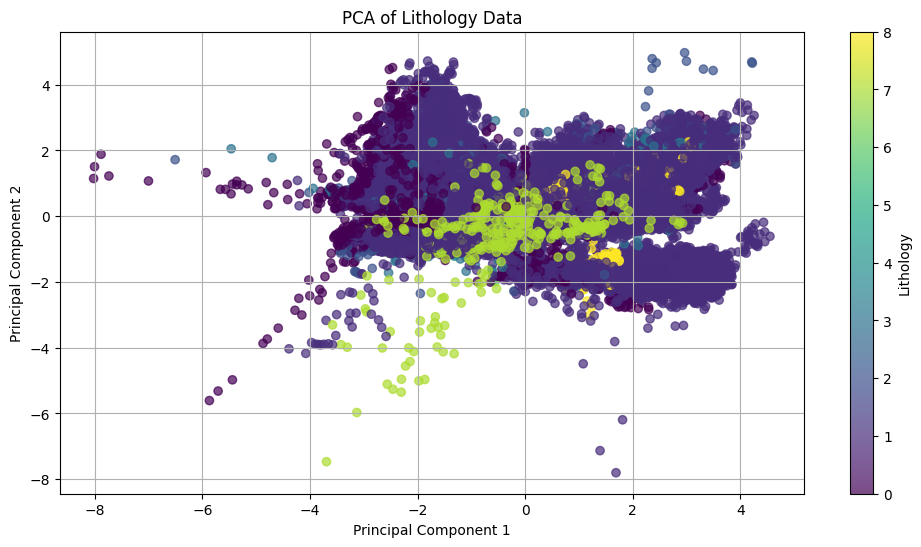

In [12]:
from sklearn.decomposition import PCA

PCA_2components = PCA(n_components=2)

# Project the original data into the PCA space
Result = PCA_2components.fit_transform(pca_df)

print("The eigenvalues:", PCA_2components.explained_variance_)

# Print the values of the first component 
print("Some first samples of the transformed data: \n", Result[:5,:])

# Plot the PCA results
plt.figure(figsize=(12, 6))
plt.scatter(Result[:, 0], Result[:, 1], c=DFLabel.astype('category').cat.codes, cmap='viridis', alpha=.7)
plt.title("PCA of Lithology Data")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.colorbar(label='Lithology')
plt.grid(True)
plt.show()

In [13]:
import plotly.express as px
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}

palette = ["#6528F7", "#7E2553", "#FF004D", "#379237", "#EA047E", "#45FFCA", "#071952"]

fig = px.scatter(
    x=Result[:, 0],
    y=Result[:, 1],
    color=DFLabel.map(litho_code),
    color_discrete_sequence=palette,
    labels={'x': 'Principal Component 1', 'y': 'Principal Component 2', 'color': 'Lithology'},
    title='PCA of Lithology Data',
    width=1000,
    height=600
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
    yaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black')
)

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.show()

[4.36905568 5.90570176]
[0.33607324 0.11820074]


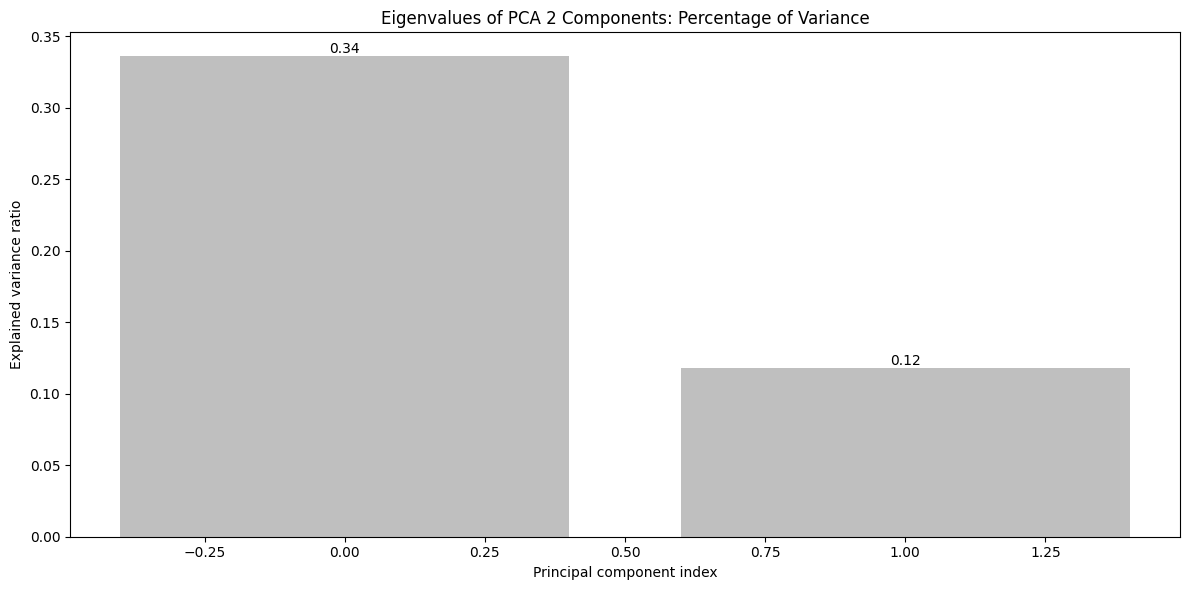

In [14]:
fig_2c_pca = plt.figure()
fig_2c_pca.set_size_inches(12, 6)
ACCUM_eigenvalues = np.cumsum(PCA_2components.explained_variance_)
print(ACCUM_eigenvalues)
print(PCA_2components.explained_variance_ratio_)
plt.bar(range(0, len(PCA_2components.explained_variance_ratio_)), PCA_2components.explained_variance_ratio_, 
        alpha=0.5, color='grey', align='center', label='Individual Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues of PCA 2 Components: Percentage of Variance")

# Add the value on top of each bar
for i, value in enumerate(PCA_2components.explained_variance_ratio_):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Accumulated explained variance ratio: [0.33607324 0.45427398]


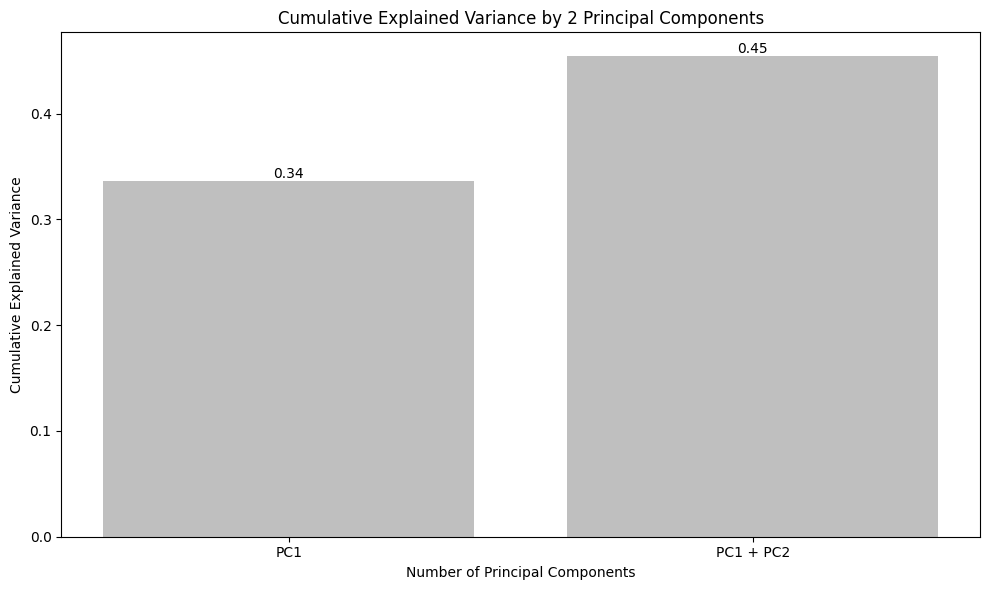

In [15]:
# Calculate accumulated explained_variance_ratio_
accumulated_variance = np.cumsum(PCA_2components.explained_variance_ratio_)
print("Accumulated explained variance ratio:", accumulated_variance)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(accumulated_variance) + 1), accumulated_variance, alpha=0.5, color='grey', align='center', label='Cumulative Explained Variance')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by 2 Principal Components')
plt.xticks(range(1, len(accumulated_variance) + 1), ['PC1', 'PC1 + PC2'])

# Add the value on top of each bar
for i, value in enumerate(accumulated_variance):
    plt.text(i + 1, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [16]:
shape = PCA_2components.components_.shape[0]

most_important = [np.abs(PCA_2components.components_[i]).argmax() for i in range(shape)]
most_important_names = [feature_names[most_important[i]] for i in range(shape)]

# Build a doctionary of the imprtant features by PC
MyDic = {'PC{}'.format(i): most_important_names[i] for i in range(shape)}

# build the dataframe
Important_DF = pd.DataFrame(MyDic.items())
print(Important_DF)

     0     1
0  PC0   DTC
1  PC1  DRHO


### 6. PCA with `n_components = 3`

In [17]:
PCA_3components = PCA(n_components=3)

# Project the original data into the PCA space
Result = PCA_3components.fit_transform(pca_df)

print("The eigenvalues:", PCA_3components.explained_variance_)

# Print the values of the first component 
print("Some first samples of the transformed data: \n", Result[:5,:])

The eigenvalues: [4.36905568 1.53664608 1.26636894]
Some first samples of the transformed data: 
 [[ 2.42653505  0.22702105 -0.31328852]
 [ 2.43283466  0.13501467 -0.26520136]
 [ 2.43892402  0.05219493 -0.21188984]
 [ 2.42813326 -0.03215117 -0.20104732]
 [ 2.37508632 -0.09713344 -0.24734197]]


[4.36905568 5.90570176 7.1720707 ]
[0.33607324 0.11820074 0.09741069]


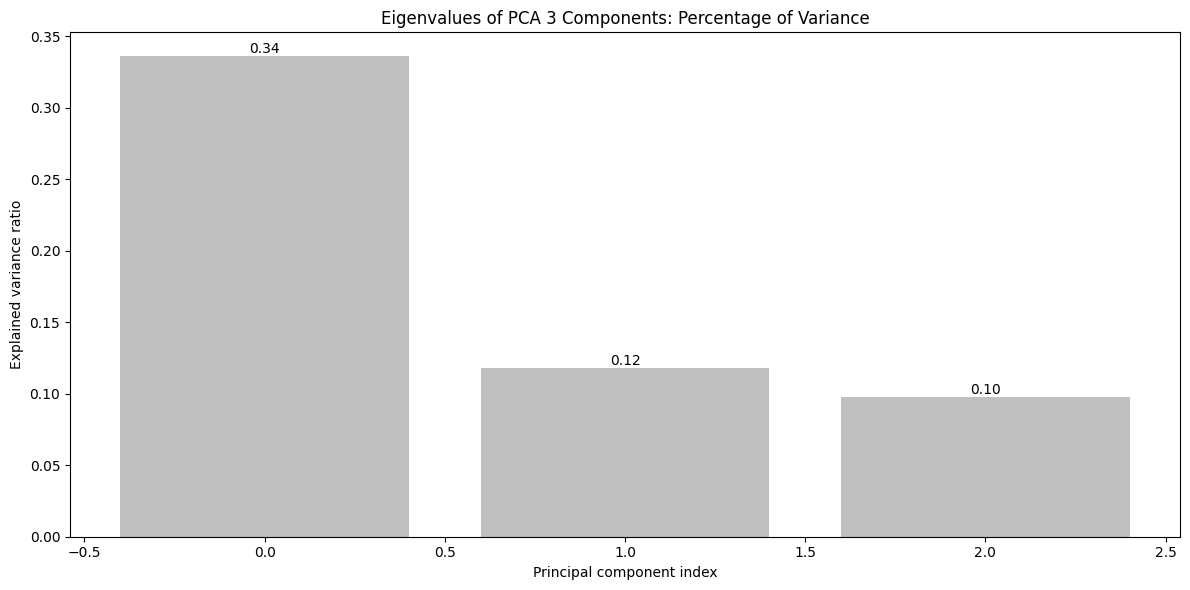

In [18]:
fig_3c_pca=plt.figure()
fig_3c_pca.set_size_inches(12, 6)
ACCUM_eigenvalues = np.cumsum(PCA_3components.explained_variance_)
print(ACCUM_eigenvalues)
print(PCA_3components.explained_variance_ratio_)
plt.bar(range(0,len(PCA_3components.explained_variance_ratio_)), PCA_3components.explained_variance_ratio_, 
        alpha=0.5, color='grey', align='center', label='Individual Explained Variances')
# plt.step(range(0,len(ACCUM_eigenvalues)), ACCUM_eigenvalues, where='mid',label='Cumulative Explained Variances')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title("Eigenvalues of PCA 3 Components: Percentage of Variance")
#plt.legend(loc='best')
# Add the value on top of each bar
for i, value in enumerate(PCA_3components.explained_variance_ratio_):
    plt.text(i, value, f'{value:.2f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

Accumulated explained variance ratio: [0.33607324 0.45427398 0.55168467]


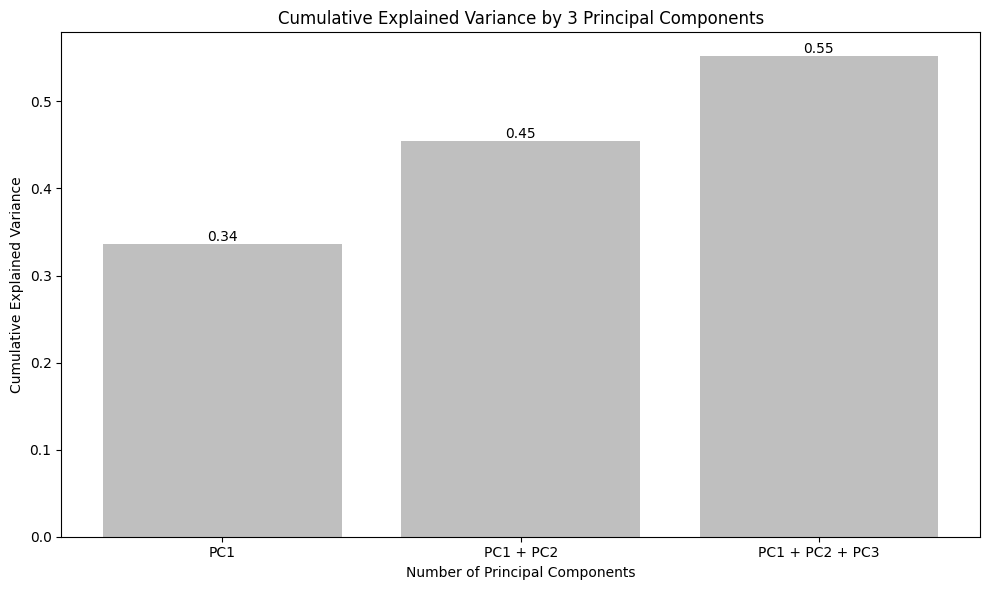

In [19]:
# Calculate accumulated explained_variance_ratio_
accumulated_variance = np.cumsum(PCA_3components.explained_variance_ratio_)
print("Accumulated explained variance ratio:", accumulated_variance)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(accumulated_variance) + 1), accumulated_variance, alpha=0.5, align='center', label='Cumulative Explained Variance', color='grey')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by 3 Principal Components')
plt.xticks(range(1, len(accumulated_variance) + 1), ['PC1', 'PC1 + PC2', 'PC1 + PC2 + PC3'])

# Add the value on top of each bar
for i, value in enumerate(accumulated_variance):
    plt.text(i + 1, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

In [20]:
MyCov=np.cov(Result.T)

# The variance here (on the diagonal) will match the eigenvalues
print("Covar of the PC PCA Matrix: \n", MyCov)
print("\nThe relative eigenvalues are:",PCA_3components.explained_variance_ratio_)
print("\nThe actual eigenvalues are:", PCA_3components.explained_variance_)
EVects=PCA_3components.components_
print("\nThe eigenvectors are:\n",EVects)
print("\nEVects Type:", type(EVects))
print("\nThe shape of the eigenvector matrix is\n", EVects.shape)
print("\nDF Shape:", pca_df.shape)
# Proof to transform origial data to eigenbasis
# Using the eigenvectors matrix.
# print(EVects.T[:5])
#  (15, 4) @ (4, 3)
Transf=pca_df@EVects.T
print("\nProof that the transformed data is the EVects @ Data\n",Transf[:5])

# Top 3 eigenvectors
top_3_eigenvectors = EVects[:3]
# Top 3 eigenvalues
top_3_eigenvalues = PCA_3components.explained_variance_[:3]
# Print
print("Top 3 eigenvectors:\n", top_3_eigenvectors)
print("Top 3 eigenvalues:\n", top_3_eigenvalues)

Covar of the PC PCA Matrix: 
 [[ 4.36905568e+00 -1.61042877e-16 -2.34152300e-17]
 [-1.61042877e-16  1.53664608e+00  1.40996745e-16]
 [-2.34152300e-17  1.40996745e-16  1.26636894e+00]]

The relative eigenvalues are: [0.33607324 0.11820074 0.09741069]

The actual eigenvalues are: [4.36905568 1.53664608 1.26636894]

The eigenvectors are:
 [[-0.42002806  0.36144063 -0.09439038 -0.05256419 -0.04161435 -0.40253559
   0.06163237  0.40501644  0.03660654  0.44227281 -0.29157336  0.23986039
   0.10083519]
 [ 0.14423038  0.15196344  0.02993113 -0.09413553 -0.08562073 -0.11717338
  -0.06958591 -0.18884323 -0.02746499  0.09757295  0.55625118  0.36391811
   0.65776614]
 [ 0.08625445 -0.25748013  0.08693142  0.32335299  0.34770561  0.07072878
   0.60129935  0.19064785 -0.46665016  0.08095497  0.00788681  0.24153835
   0.08730181]]

EVects Type: <class 'numpy.ndarray'>

The shape of the eigenvector matrix is
 (3, 13)

DF Shape: (42181, 13)

Proof that the transformed data is the EVects @ Data
 [[ 2.42

In [21]:
# Top 3 eigenvalues
top_3_eigenvalues = PCA_3components.explained_variance_
print("Top 3 eigenvalues:\n", top_3_eigenvalues)

Top 3 eigenvalues:
 [4.36905568 1.53664608 1.26636894]


In [22]:
top_3_eigenvectors = EVects[:3]
print("Top 3 eigenvectors:\n", top_3_eigenvectors)

Top 3 eigenvectors:
 [[-0.42002806  0.36144063 -0.09439038 -0.05256419 -0.04161435 -0.40253559
   0.06163237  0.40501644  0.03660654  0.44227281 -0.29157336  0.23986039
   0.10083519]
 [ 0.14423038  0.15196344  0.02993113 -0.09413553 -0.08562073 -0.11717338
  -0.06958591 -0.18884323 -0.02746499  0.09757295  0.55625118  0.36391811
   0.65776614]
 [ 0.08625445 -0.25748013  0.08693142  0.32335299  0.34770561  0.07072878
   0.60129935  0.19064785 -0.46665016  0.08095497  0.00788681  0.24153835
   0.08730181]]


In [23]:
import plotly.express as px
litho_code = {30000: "Sandstone", 65030: "SandstoneShale", 65000: "Shale", 80000: "Marl", 
            74000: "Dolomite", 70000: "Limestone", 70032: "Chalk", 88000: "Halite", 
            86000: "Anhydrite", 99000: "Tuff", 90000: "Coal", 93000: "Basement"}

palette = ["#6528F7", "#7E2553", "#FF004D", "#379237", "#EA047E", "#45FFCA", "#071952"]

fig = px.scatter(
    x=Result[:, 0],
    y=Result[:, 1],
    color=DFLabel.map(litho_code),
    color_discrete_sequence=palette,
    labels={'x': 'Principal Component 1', 'y': 'Principal Component 2', 'color': 'Lithology'},
    title='PCA of Lithology Data',
    width=1000,
    height=600
)

fig.update_layout(
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
    yaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black')
)

fig.update_traces(marker=dict(size=5, opacity=0.7))
fig.show()

In [24]:
import plotly.express as px

fig = px.scatter_3d(
    x=Result[:, 2],
    y=Result[:, 1],
    z=Result[:, 0],
    color=DFLabel.map(litho_code),
    # color=DFLabel.astype(str),
    labels={'x': 'PC2', 'y': 'PC1', 'z': 'PC0', 'color': 'Lithology'},
    title='3D PCA',
    width=1000,
    height=600
)
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
        yaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black'),
        zaxis=dict(showgrid=True, gridcolor='grey', zeroline=True, zerolinecolor='black')
    ),
    plot_bgcolor='white',
    paper_bgcolor='white'
)

fig.update_traces(marker=dict(size=3, opacity=0.7))

fig.show()


In [25]:
shape= PCA_3components.components_.shape[0]

most_important = [np.abs(PCA_3components.components_[i]).argmax() for i in range(shape)]
most_important_names = [feature_names[most_important[i]] for i in range(shape)]

# Build a doctionary of the imprtant features by PC
MyDic = {'PC{}'.format(i): most_important_names[i] for i in range(shape)}

# build the dataframe
Important_DF = pd.DataFrame(MyDic.items())
print(Important_DF)

     0     1
0  PC0   DTC
1  PC1  DRHO
2  PC2    GR


### 7. Accumulated 95% PCA data

The eigenvalues: [4.36905568 1.53664608 1.26636894 1.1585706  1.06048794 0.96230882
 0.80664877 0.63333098 0.45188033 0.29530786 0.21917102 0.14882797
 0.09170322]
Accumulated explained variance ratio: [0.33607324 0.45427398 0.55168467 0.64080337 0.72237743 0.79639943
 0.85844787 0.90716448 0.94192368 0.96463913 0.98149804 0.99294607
 1.        ]


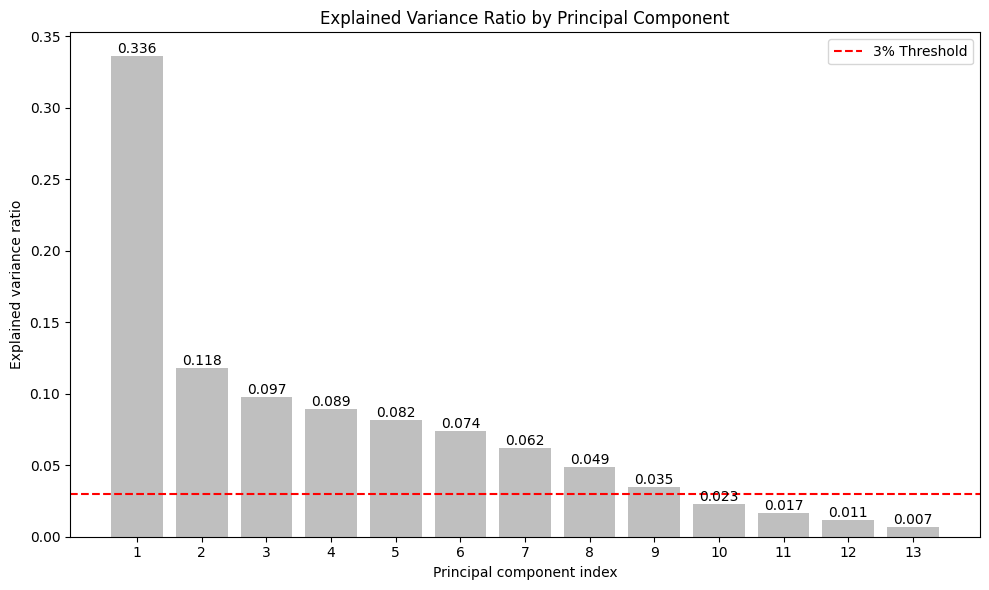

In [26]:
PCA_all_components = PCA(n_components=13)

# Project the original data into the PCA space
Result = PCA_all_components.fit_transform(pca_df)

print("The eigenvalues:", PCA_all_components.explained_variance_)

# Calculate accumulated explained_variance_ratio_
accumulated_variance = np.cumsum(PCA_all_components.explained_variance_ratio_)
print("Accumulated explained variance ratio:", accumulated_variance)

# Barplot of explained variance ratio
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(PCA_all_components.explained_variance_ratio_) + 1), PCA_all_components.explained_variance_ratio_, alpha=0.5, align='center', color='grey')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Explained Variance Ratio by Principal Component')
plt.xticks(range(1, len(PCA_all_components.explained_variance_ratio_) + 1))
plt.axhline(y=0.03, color='r', linestyle='--', label='3% Threshold')

# Add the value on top of each bar
for i, value in enumerate(PCA_all_components.explained_variance_ratio_):
    plt.text(i + 1, value, f'{value:.3f}', ha='center', va='bottom')

plt.legend()
plt.tight_layout()
plt.show()

8 features cover up to 90% the variance of the data and 10 out of 14 features cancover 95% of the data

Accumulated explained variance ratio: [0.33607324 0.45427398 0.55168467 0.64080337 0.72237743 0.79639943
 0.85844787 0.90716448 0.94192368 0.96463913 0.98149804 0.99294607
 1.        ]


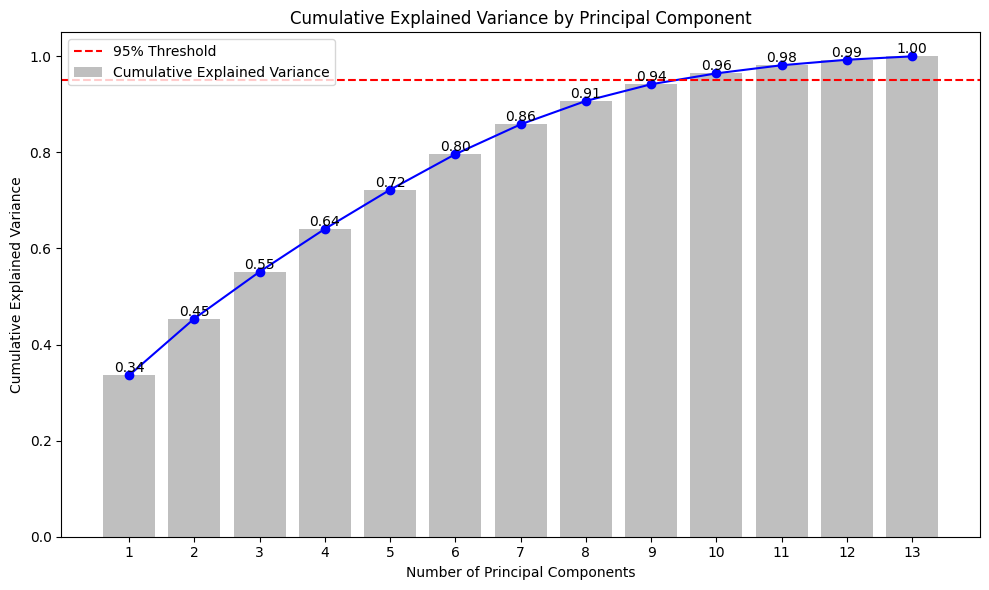

In [27]:
# Calculate accumulated explained_variance_ratio_
accumulated_variance = np.cumsum(PCA_all_components.explained_variance_ratio_)
print("Accumulated explained variance ratio:", accumulated_variance)

# Plot the cumulative explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(accumulated_variance) + 1), accumulated_variance, alpha=0.5, align='center', label='Cumulative Explained Variance', color='grey')
plt.plot(range(1, len(accumulated_variance) + 1), accumulated_variance, marker='o', linestyle='-', color='b')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.ylabel('Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.title('Cumulative Explained Variance by Principal Component')
plt.xticks(range(1, len(accumulated_variance) + 1))

# Add the value on top of each bar
for i, value in enumerate(accumulated_variance):
    plt.text(i + 1, value, f'{value:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.legend()
plt.show()

In [28]:
shape= PCA_all_components.components_.shape[0]

most_important = [np.abs(PCA_all_components.components_[i]).argmax() for i in range(shape)]
most_important_names = [feature_names[most_important[i]] for i in range(shape)]

# Build a doctionary of the imprtant features by PC
MyDic = {'PC{}'.format(i): most_important_names[i] for i in range(shape)}

# build the dataframe
Important_DF = pd.DataFrame(MyDic.items())
print(Important_DF)

       0         1
0    PC0       DTC
1    PC1      DRHO
2    PC2        GR
3    PC3      RMED
4    PC4       PEF
5    PC5      RSHA
6    PC6      RMED
7    PC7       ROP
8    PC8      RHOB
9    PC9      CALI
10  PC10  DEPTH_MD
11  PC11       DTC
12  PC12      NPHI
